#  NOVA Tutorial 5: Integrated Math & Visualization Tools

NOVA includes integrated mathematical tools optimized for astronomical data
processing, and easy-to-use visualization functions. No external dependencies
beyond NumPy and matplotlib are required.

**Math Tools (`nova.math`):**
- Sigma clipping & robust statistics
- FFT-based 2D convolution & smoothing
- Image rebinning & resizing
- Image stacking (mean, median, sigma-clip)
- Background estimation
- Source detection
- Aperture photometry
- Continuum normalization (spectral)
- Cosmic ray cleaning

**Visualization Tools (`nova.viz`):**
- `display_image` -- Quick-look astronomical images
- `display_rgb` -- Three-colour composites
- `display_spectrum` -- 1-D spectral plots
- `display_histogram` -- Pixel distributions
- `display_cutout` -- Region zoom
- `display_comparison` -- Side-by-side comparison
- `display_mosaic` -- Multi-panel grids
- `display_provenance` -- Provenance chain diagrams

In [1]:
%matplotlib inline
# Setup
import sys
sys.path.insert(0, "../nova-py")

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import nova
from nova import math as nmath
from nova import viz

print(f"NOVA version: {nova.__version__}")

NOVA version: 0.3.0


## Part 1: Statistical Tools

### 1.1 Sigma Clipping

Iteratively reject outliers from data -- essential for astronomical background estimation.

In [2]:
# Generate data with outliers
rng = np.random.default_rng(42)
data = rng.normal(100, 10, 10000)
data[:50] = rng.uniform(500, 1000, 50)  # Outliers

# Sigma clip
clipped = nmath.sigma_clip(data, sigma=3.0)
print(f"Original: {len(data)} points")
print(f"After 3sigma clip: {clipped.compressed().size} points ({clipped.mask.sum()} rejected)")

# Compare statistics
print(f"\nBefore clipping: mean={np.mean(data):.1f}, std={np.std(data):.1f}")
print(f"After clipping:  mean={np.mean(clipped.compressed()):.1f}, std={np.std(clipped.compressed()):.1f}")

Original: 10000 points
After 3sigma clip: 9915 points (85 rejected)

Before clipping: mean=103.2, std=48.4
After clipping:  mean=99.9, std=9.9


### 1.2 Robust Statistics

Biweight estimators are resistant to outliers -- ideal for real astronomical data.

In [3]:
# Robust statistics
stats = nmath.robust_statistics(data)
print("Robust Statistics:")
for key, val in stats.items():
    print(f"  {key:>20s}: {val:.3f}")

# Compare with sigma-clipped stats
sc_stats = nmath.sigma_clipped_stats(data, sigma=3.0)
print("\nSigma-Clipped Stats:")
for key, val in sc_stats.items():
    print(f"  {key:>8s}: {val:.3f}" if isinstance(val, float) else f"  {key:>8s}: {val}")

Robust Statistics:
                median: 99.918
                   mad: 6.690
     biweight_location: 99.894
        biweight_scale: 10.107

Sigma-Clipped Stats:
      mean: 99.883
    median: 99.857
       std: 9.906
       min: 70.142
       max: 129.142
     count: 9915


## Part 2: Image Convolution & Smoothing

### 2.1 Gaussian Kernels

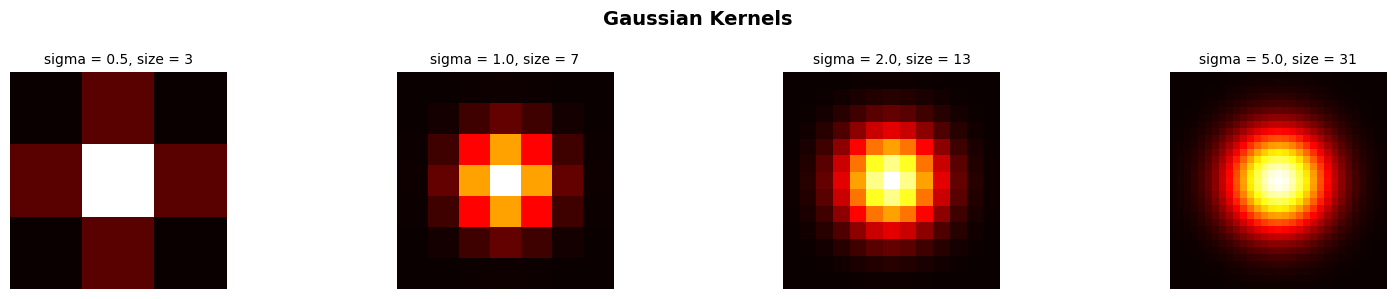

In [4]:
from IPython.display import display
# Create Gaussian kernels of different sizes
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, sigma in zip(axes, [0.5, 1.0, 2.0, 5.0]):
    kernel = nmath.gaussian_kernel_2d(sigma)
    ax.imshow(kernel, cmap="hot")
    ax.set_title(f"sigma = {sigma}, size = {kernel.shape[0]}", fontsize=10)
    ax.axis("off")
plt.suptitle("Gaussian Kernels", fontsize=14, fontweight="bold")
plt.tight_layout()
display(fig)
plt.close(fig)


### 2.2 FFT Convolution with NaN Handling

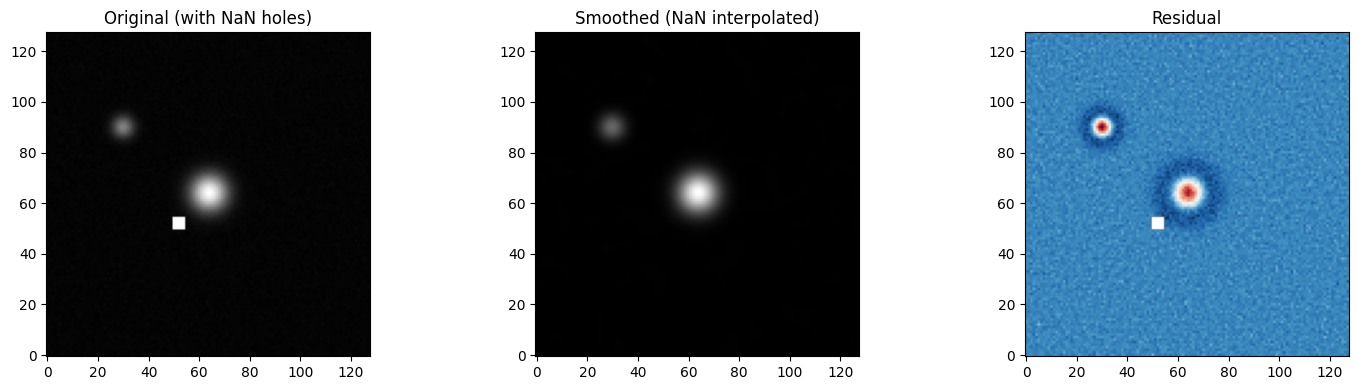

In [5]:
from IPython.display import display
# Create a test image with sources and NaN pixels
image = np.zeros((128, 128))
yy, xx = np.ogrid[0:128, 0:128]
image += 1000 * np.exp(-((xx-64)**2 + (yy-64)**2) / (2*5**2))
image += 500 * np.exp(-((xx-30)**2 + (yy-90)**2) / (2*3**2))
image += rng.normal(0, 5, (128, 128))

# Add NaN holes (simulating bad pixels)
image[50:55, 50:55] = np.nan

# Smooth with NaN interpolation
kernel = nmath.gaussian_kernel_2d(2.0)
smoothed = nmath.convolve_fft(image, kernel, nan_treatment="interpolate")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(image, origin="lower", cmap="gray")
axes[0].set_title("Original (with NaN holes)")
axes[1].imshow(smoothed, origin="lower", cmap="gray")
axes[1].set_title("Smoothed (NaN interpolated)")
axes[2].imshow(image - smoothed, origin="lower", cmap="RdBu_r")
axes[2].set_title("Residual")
plt.tight_layout()
display(fig)
plt.close(fig)


## Part 3: Image Rebinning & Resizing

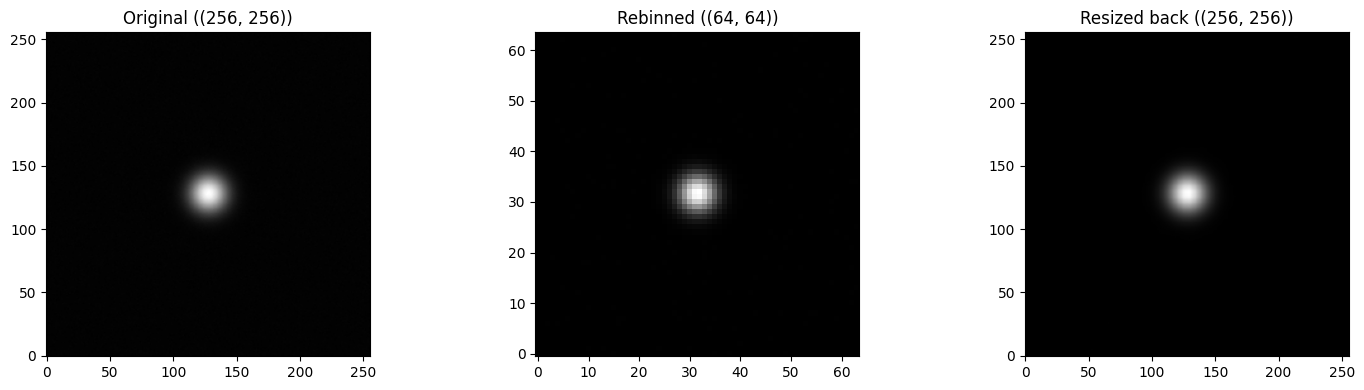

Original total flux: 16246151
Rebinned total flux: 16246151 (conserved!)


In [6]:
from IPython.display import display
# Create a test image
rng = np.random.default_rng(42)
full_image = rng.poisson(200, (256, 256)).astype(float)
yy, xx = np.ogrid[0:256, 0:256]
full_image += 5000 * np.exp(-((xx-128)**2 + (yy-128)**2) / (2*10**2))

# Rebin (downsample by summing)
rebinned = nmath.rebin(full_image, (64, 64), method="sum")

# Resize (interpolated)
resized_up = nmath.resize_image(rebinned, (256, 256), order=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(full_image, origin="lower", cmap="gray")
axes[0].set_title(f"Original ({full_image.shape})")
axes[1].imshow(rebinned, origin="lower", cmap="gray")
axes[1].set_title(f"Rebinned ({rebinned.shape})")
axes[2].imshow(resized_up, origin="lower", cmap="gray")
axes[2].set_title(f"Resized back ({resized_up.shape})")
plt.tight_layout()
display(fig)
plt.close(fig)

print(f"Original total flux: {full_image.sum():.0f}")
print(f"Rebinned total flux: {rebinned.sum():.0f} (conserved!)")

## Part 4: Spectral Analysis Tools

### 4.1 Continuum Normalization

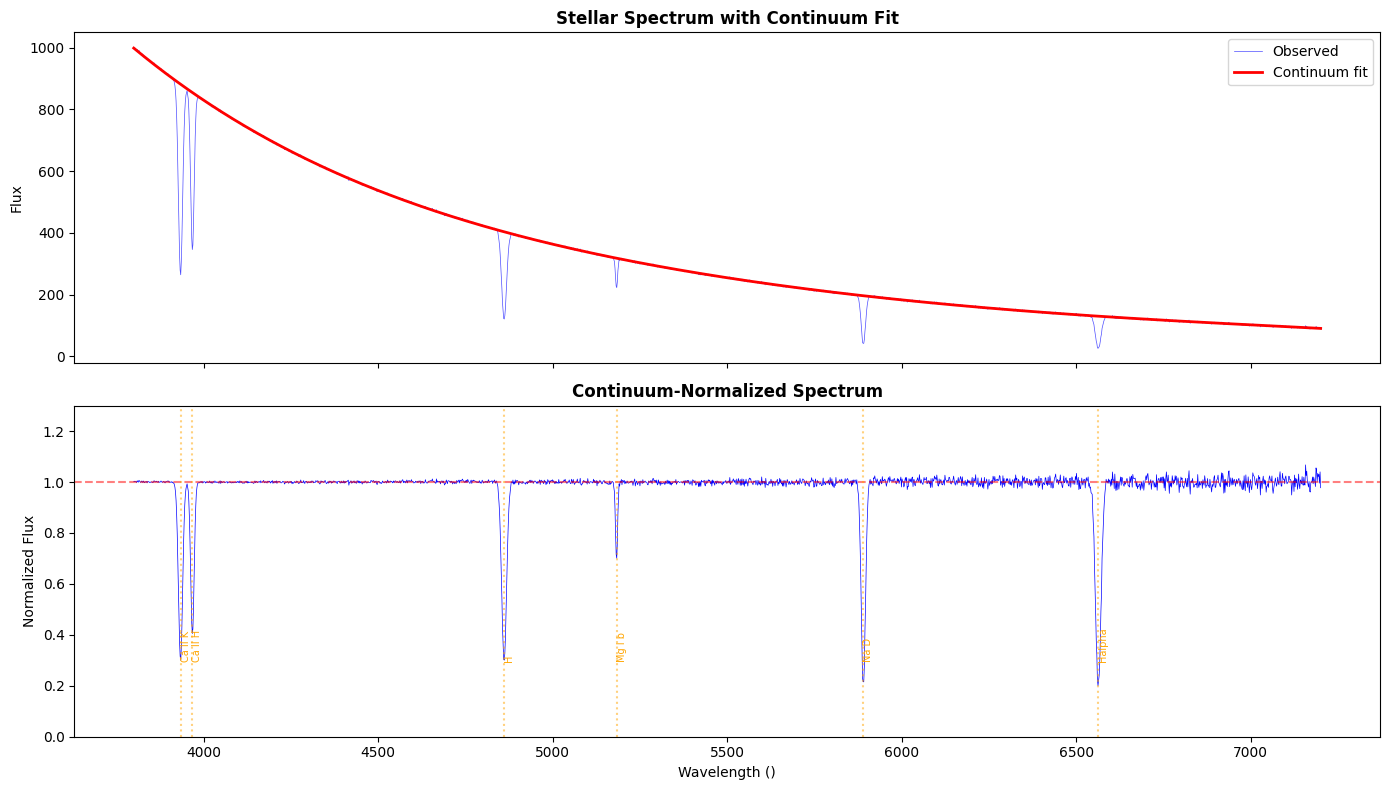

In [7]:
from IPython.display import display
# Generate a realistic stellar spectrum
wavelength = np.linspace(3800, 7200, 2048)

# Blackbody-ish continuum
T = 5800  # Solar temperature
flux = 1e10 / (wavelength**5 * (np.exp(1.44e7 / (wavelength * T)) - 1))
flux = flux / np.max(flux) * 1000

# Add absorption lines
lines = [
    (3934, 30, 0.7, "Ca II K"),
    (3968, 25, 0.6, "Ca II H"),
    (4861, 35, 0.7, "H"),
    (5183, 15, 0.3, "Mg I b"),
    (5890, 30, 0.8, "Na D"),
    (6563, 40, 0.8, "Halpha"),
]
for wl, width, depth, _ in lines:
    flux *= 1 - depth * np.exp(-0.5 * ((wavelength - wl) / width * 5)**2)

flux = np.abs(flux) + rng.normal(0, 2, len(flux))

# Continuum normalize
norm_flux, continuum = nmath.continuum_normalize(wavelength, flux)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(wavelength, flux, "b-", linewidth=0.5, alpha=0.7, label="Observed")
ax1.plot(wavelength, continuum, "r-", linewidth=2, label="Continuum fit")
ax1.set_ylabel("Flux")
ax1.set_title("Stellar Spectrum with Continuum Fit", fontweight="bold")
ax1.legend()

ax2.plot(wavelength, norm_flux, "b-", linewidth=0.5)
ax2.axhline(1.0, color="red", linestyle="--", alpha=0.5)
for wl, _, _, name in lines:
    ax2.axvline(wl, color="orange", linestyle=":", alpha=0.5)
    ax2.text(wl, 0.3, name, rotation=90, fontsize=7, color="orange")
ax2.set_xlabel("Wavelength ()")
ax2.set_ylabel("Normalized Flux")
ax2.set_title("Continuum-Normalized Spectrum", fontweight="bold")
ax2.set_ylim(0, 1.3)

plt.tight_layout()
display(fig)
plt.close(fig)


### 4.2 Equivalent Width Measurement

In [8]:
# Measure equivalent widths of absorption lines
print("Equivalent Width Measurements:")
print(f"{'Line':>10s}  {' ()':>8s}  {'EW ()':>8s}")
print("-" * 32)
for wl, _, _, name in lines:
    ew = nmath.equivalent_width(wavelength, norm_flux, wl, 100)
    print(f"{name:>10s}  {wl:8.0f}  {ew:8.2f}")

Equivalent Width Measurements:
      Line        ()     EW ()
--------------------------------
   Ca II K      3934     18.03
   Ca II H      3968     18.06
         H      4861     12.17
    Mg I b      5183      2.50
      Na D      5890     11.78
    Halpha      6563     15.79


## Part 5: Visualization Tools Gallery

### 5.1 Display Functions

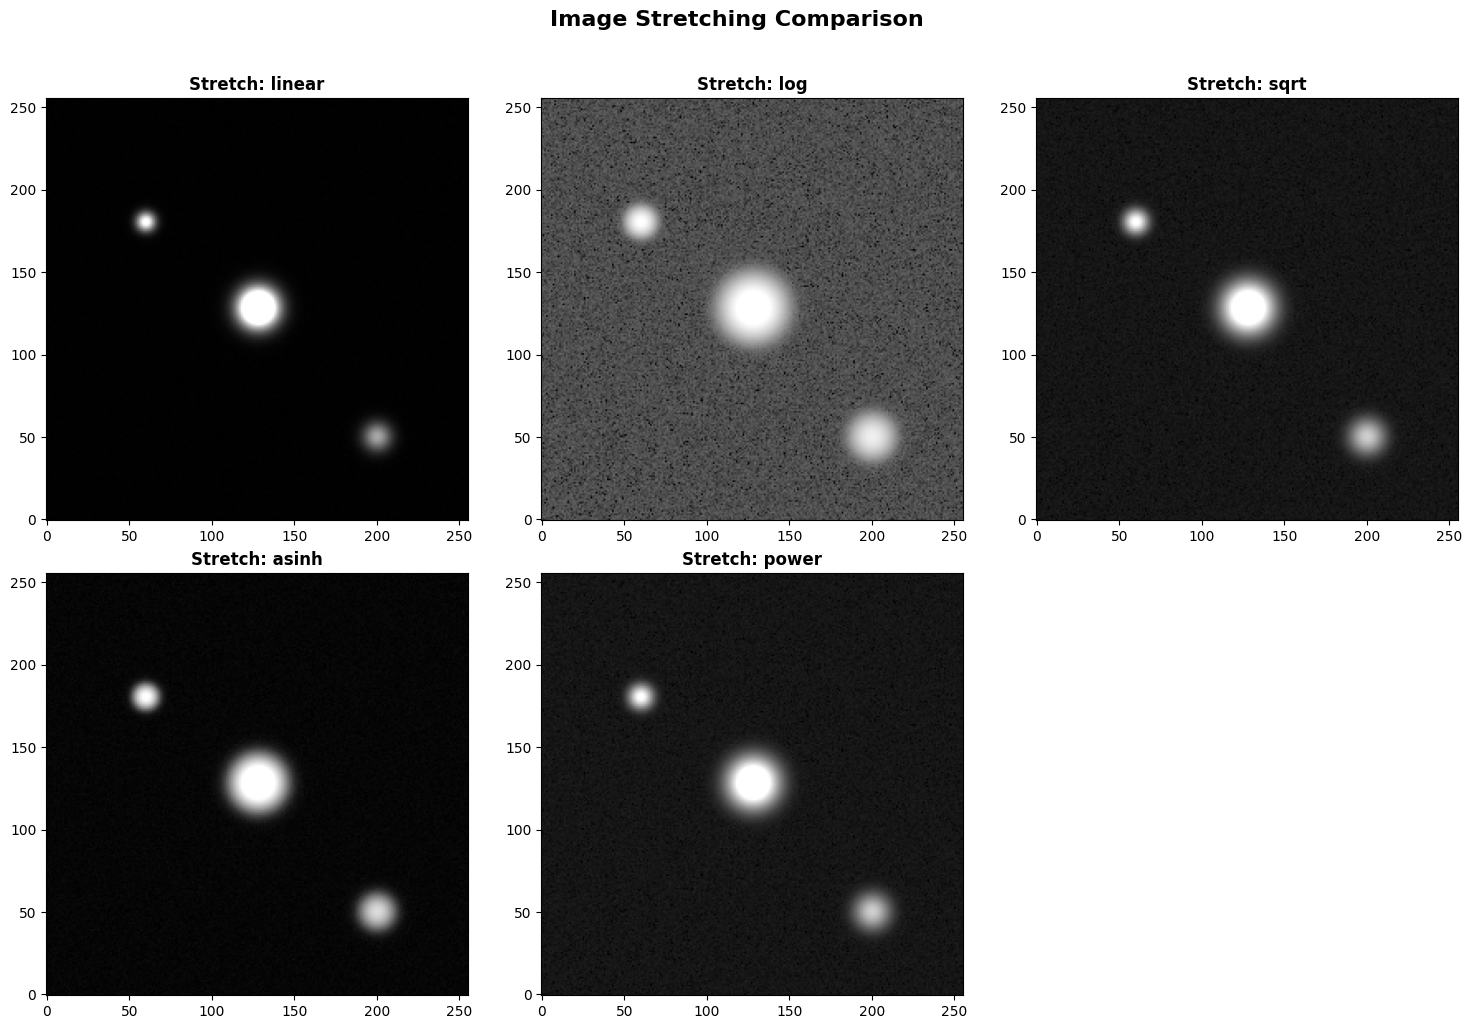

In [9]:
from IPython.display import display
# Generate a rich test image
sky = rng.poisson(200, (256, 256)).astype(float)
yy, xx = np.ogrid[0:256, 0:256]
sky += 10000 * np.exp(-((xx-128)**2 + (yy-128)**2) / (2*8**2))
sky += 5000 * np.exp(-((xx-60)**2 + (yy-180)**2) / (2*4**2))
sky += 3000 * np.exp(-((xx-200)**2 + (yy-50)**2) / (2*6**2))

# Different stretches
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
stretches = ["linear", "log", "sqrt", "asinh", "power"]
for ax, stretch in zip(axes.flat, stretches):
    fig_inner = viz.display_image(sky, title=f"Stretch: {stretch}", 
                                   stretch=stretch, colorbar=False, figsize=(5, 5))
    # Re-render inline
    from nova.visualization import _apply_stretch, _percentile_interval
    vmin, vmax = _percentile_interval(sky, 99.5)
    display_data = np.clip(sky, vmin, vmax)
    display_data = _apply_stretch(display_data, stretch=stretch)
    ax.imshow(display_data, origin="lower", cmap="gray")
    ax.set_title(f"Stretch: {stretch}", fontweight="bold")
    plt.close(fig_inner)
axes.flat[-1].set_visible(False)
plt.suptitle("Image Stretching Comparison", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
display(fig)
plt.close(fig)


### 5.2 RGB Composites

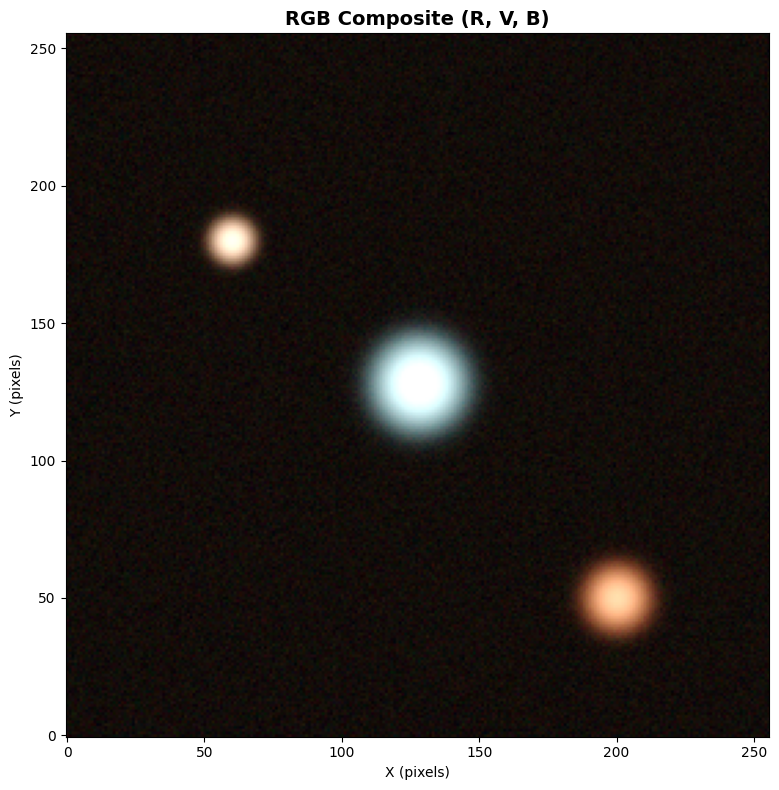

In [10]:
from IPython.display import display
# Create 3-band images (simulating B, V, R filters)
blue = rng.poisson(150, (256, 256)).astype(float)
green = rng.poisson(200, (256, 256)).astype(float)  
red = rng.poisson(250, (256, 256)).astype(float)

# Same sources, different relative brightness
for band, color_factor in [(blue, [1.2, 0.8, 0.5]),
                            (green, [1.0, 1.0, 0.8]),
                            (red, [0.5, 1.2, 1.5])]:
    band += (color_factor[0] * 5000 * np.exp(-((xx-128)**2 + (yy-128)**2) / (2*8**2))).astype(float)
    band += (color_factor[1] * 3000 * np.exp(-((xx-60)**2 + (yy-180)**2) / (2*4**2))).astype(float)
    band += (color_factor[2] * 2000 * np.exp(-((xx-200)**2 + (yy-50)**2) / (2*6**2))).astype(float)

fig = viz.display_rgb(red, green, blue, title="RGB Composite (R, V, B)", stretch="asinh")
display(fig)
plt.close(fig)


### 5.3 Spectral Display

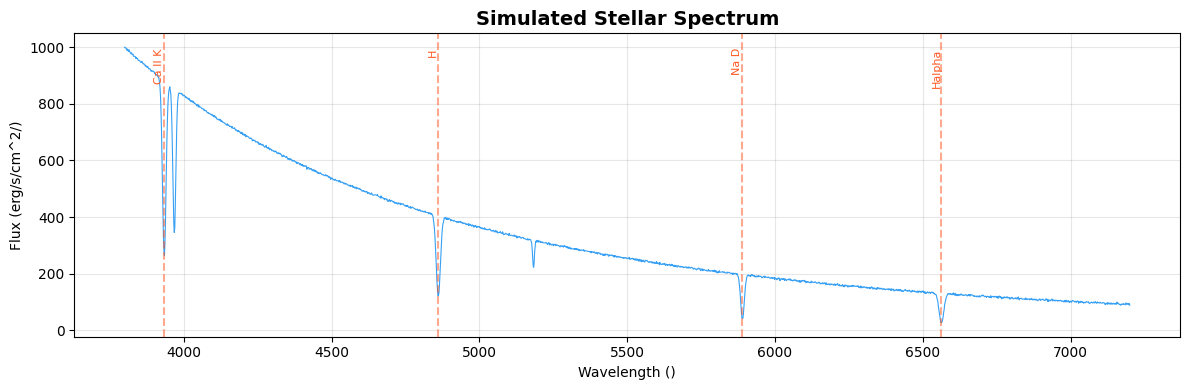

In [11]:
from IPython.display import display
# Display spectrum with line markers
line_markers = [
    {"wavelength": 3934, "name": "Ca II K"},
    {"wavelength": 4861, "name": "H"},
    {"wavelength": 5890, "name": "Na D"},
    {"wavelength": 6563, "name": "Halpha"},
]

fig = viz.display_spectrum(
    wavelength, flux,
    title="Simulated Stellar Spectrum",
    xlabel="Wavelength ()",
    ylabel="Flux (erg/s/cm^2/)",
    line_markers=line_markers,
)
display(fig)
plt.close(fig)


### 5.4 Image Comparison & Cutout

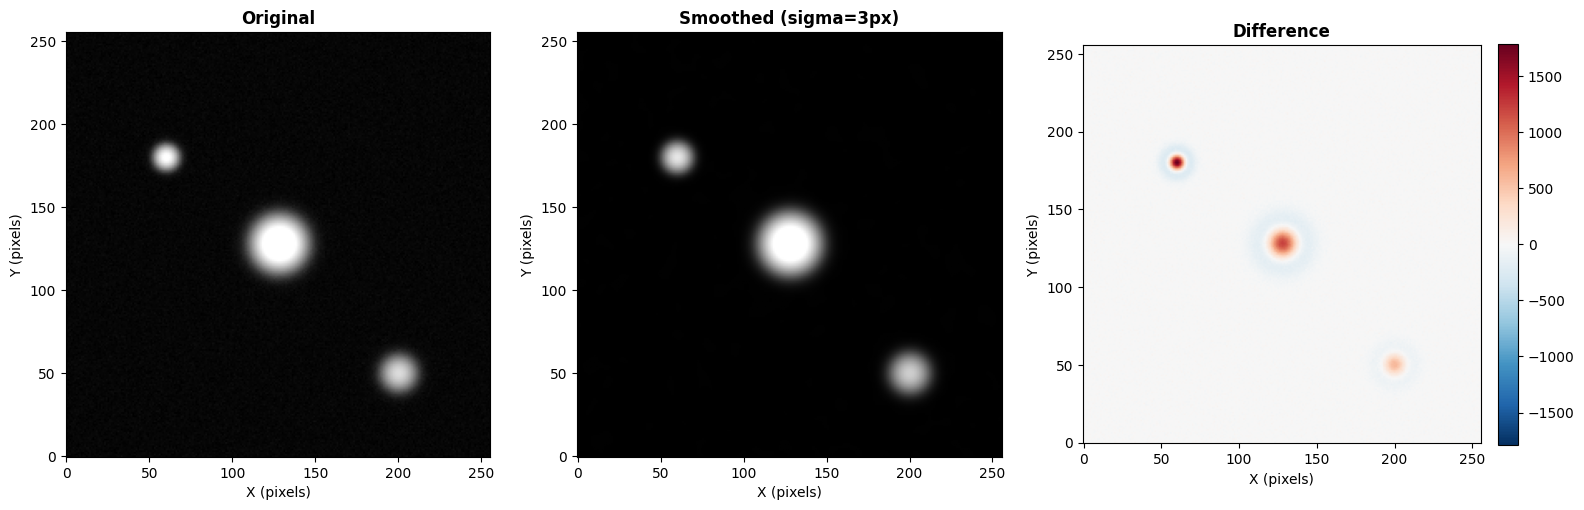

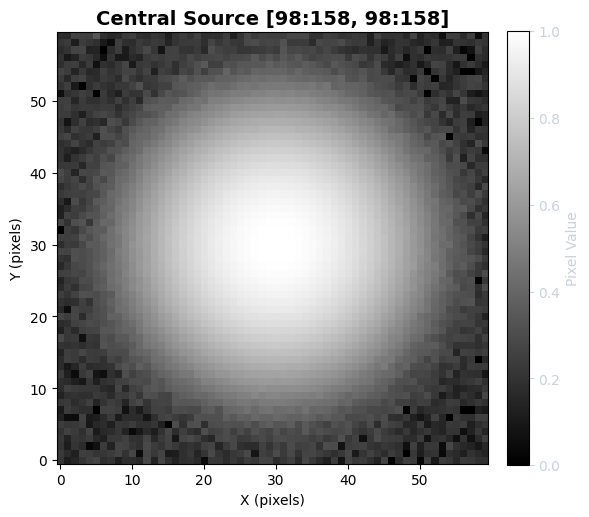

In [12]:
from IPython.display import display
# Compare original vs smoothed
smoothed_sky = nmath.smooth_gaussian(sky, sigma=3.0)
fig = viz.display_comparison(
    sky, smoothed_sky,
    title1="Original", title2="Smoothed (sigma=3px)",
    stretch="asinh",
)
display(fig)
plt.close(fig)

# Cutout of a source
fig = viz.display_cutout(sky, center=(128, 128), size=30, 
                         title="Central Source", stretch="log")
display(fig)
plt.close(fig)


### 5.5 Provenance Visualization

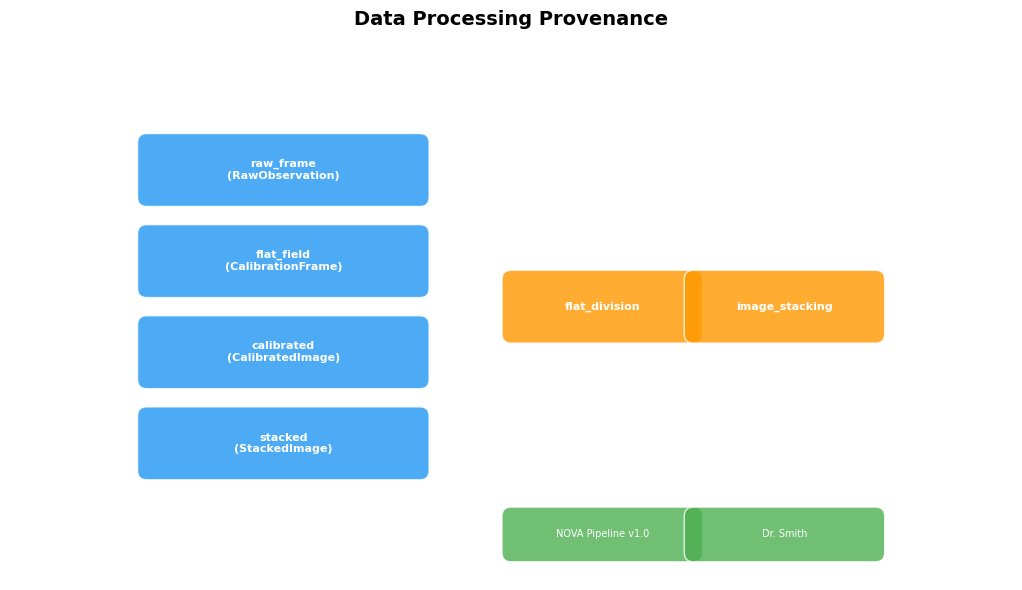

In [13]:
from IPython.display import display
# Visualize a provenance chain
prov = {
    "@type": "prov:Bundle",
    "prov:entity": [
        {"@id": "raw_frame", "nova:entity_type": "RawObservation"},
        {"@id": "flat_field", "nova:entity_type": "CalibrationFrame"},
        {"@id": "calibrated", "nova:entity_type": "CalibratedImage"},
        {"@id": "stacked", "nova:entity_type": "StackedImage"},
    ],
    "prov:activity": [
        {"@id": "flat_division"},
        {"@id": "image_stacking"},
    ],
    "prov:agent": [
        {"@id": "nova_pipeline", "nova:name": "NOVA Pipeline v1.0"},
        {"@id": "observer", "nova:name": "Dr. Smith"},
    ],
}
fig = viz.display_provenance(prov, title="Data Processing Provenance")
display(fig)
plt.close(fig)


##  Summary: NOVA Integrated Tools

### Math Tools (`nova.math`)

| Category | Functions | Use Case |
|----------|----------|----------|
| **Statistics** | `sigma_clip`, `sigma_clipped_stats`, `robust_statistics` | Background estimation, outlier rejection |
| **Convolution** | `gaussian_kernel_2d`, `convolve_fft`, `smooth_gaussian` | PSF matching, noise reduction |
| **Resampling** | `rebin`, `resize_image` | Resolution matching, mosaicking |
| **Stacking** | `stack_images` (mean/median/sigma-clip) | Combining exposures |
| **Background** | `estimate_background` | Sky subtraction |
| **Detection** | `detect_sources`, `aperture_photometry` | Source cataloging |
| **Spectral** | `continuum_normalize`, `equivalent_width` | Spectral analysis |
| **Cleaning** | `cosmic_ray_clean` | Artifact removal |

### Visualization Tools (`nova.viz`)

| Function | Description |
|----------|-------------|
| `display_image` | Quick-look with stretch, colormap, WCS |
| `display_rgb` | Three-colour composite |
| `display_spectrum` | 1-D plot with line markers |
| `display_histogram` | Pixel distribution with stats |
| `display_cutout` | Region zoom with coordinates |
| `display_comparison` | Side-by-side + difference |
| `display_mosaic` | Multi-panel grid |
| `display_provenance` | Provenance chain diagram |

**All tools are NumPy-native and optimized for performance!**